# Soal 3

Buat program untuk menghitung histogram level abu-abu (luminance) dari suatu citra dengan tahapan berikut:

a. Konversi citra warna menjadi luminasi

b. Hitung histogram, distribusi kumulatif dan fungsi pemerataan.

c. Terapkan CLAHE pada citra tersebut dan bandingkan hasilnya. Berikan penjelasan.

d. Bandingkan hasil tersebut dengan fungsi cv2.adaptiveThreshold. Berikan analisa Anda. (Tutorial: https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html )

*NOTE UNTUK ANGGOTA :*

*Kalau butuh image nya, bisa download di sini*

https://drive.google.com/file/d/1KIhdrMC0ebpaGzwCK0m7LxmK4q8Nocop/view?usp=drive_link

*Simpan di root folder di drive dan jalankan codenya*

## A. Konversi citra warna menjadi luminasi

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')
IMAGE_DIR = "/content/drive/MyDrive"

Mounted at /content/drive


array([[ 43,  46,  48, ...,  55,  53,  50],
       [ 41,  46,  50, ...,  60,  58,  55],
       [ 46,  51,  56, ...,  64,  63,  60],
       ...,
       [120, 110, 107, ..., 113, 114, 124],
       [116, 119, 108, ..., 111, 122, 117],
       [107, 118, 129, ..., 104, 105, 104]], dtype=uint8)
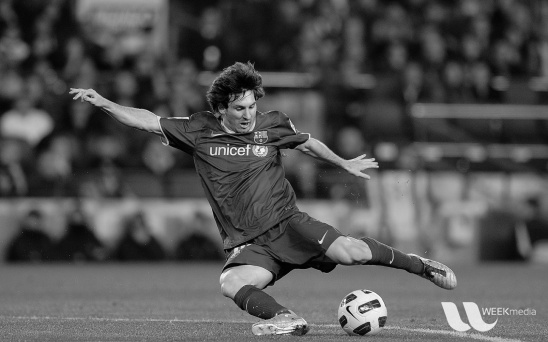

In [3]:
img_bgr = cv2.imread(f'{IMAGE_DIR}/messi5.jpg')
blue, green, red = img_bgr[:, :, 0], img_bgr[:, :, 1], img_bgr[:, :, 2]

red_luminate_weight = 0.299
green_luminate_weight = 0.587
blue_luminate_weight = 0.114

red_weighted = red * red_luminate_weight
green_weighted = green * green_luminate_weight
blue_weighted = blue * blue_luminate_weight

luminance = red_weighted + green_weighted + blue_weighted
img_gray = np.round(luminance).astype(np.uint8)

img_gray

## B. Hitung histogram, distribusi kumulatif dan fungsi pemerataan.

Memakai img_gray yang sudah ada di memori.
Shape img_gray: (342, 548), dtype: uint8
Ukuran citra          : 342 x 548 = 187416 piksel
Jumlah histogram      : 187416  (harus = N)
Sum PDF               : 1.000000  (harus ~ 1)
CDF[0], CDF[255]      : 0.000096, 1.000000
cdf_min               : 0.000096
Contoh mapping r -> s (fungsi pemerataan):
    r=  0  -->  s=  0
    r= 50  -->  s= 75
    r=100  -->  s=158
    r=128  -->  s=219
    r=200  -->  s=252
    r=255  -->  s=255


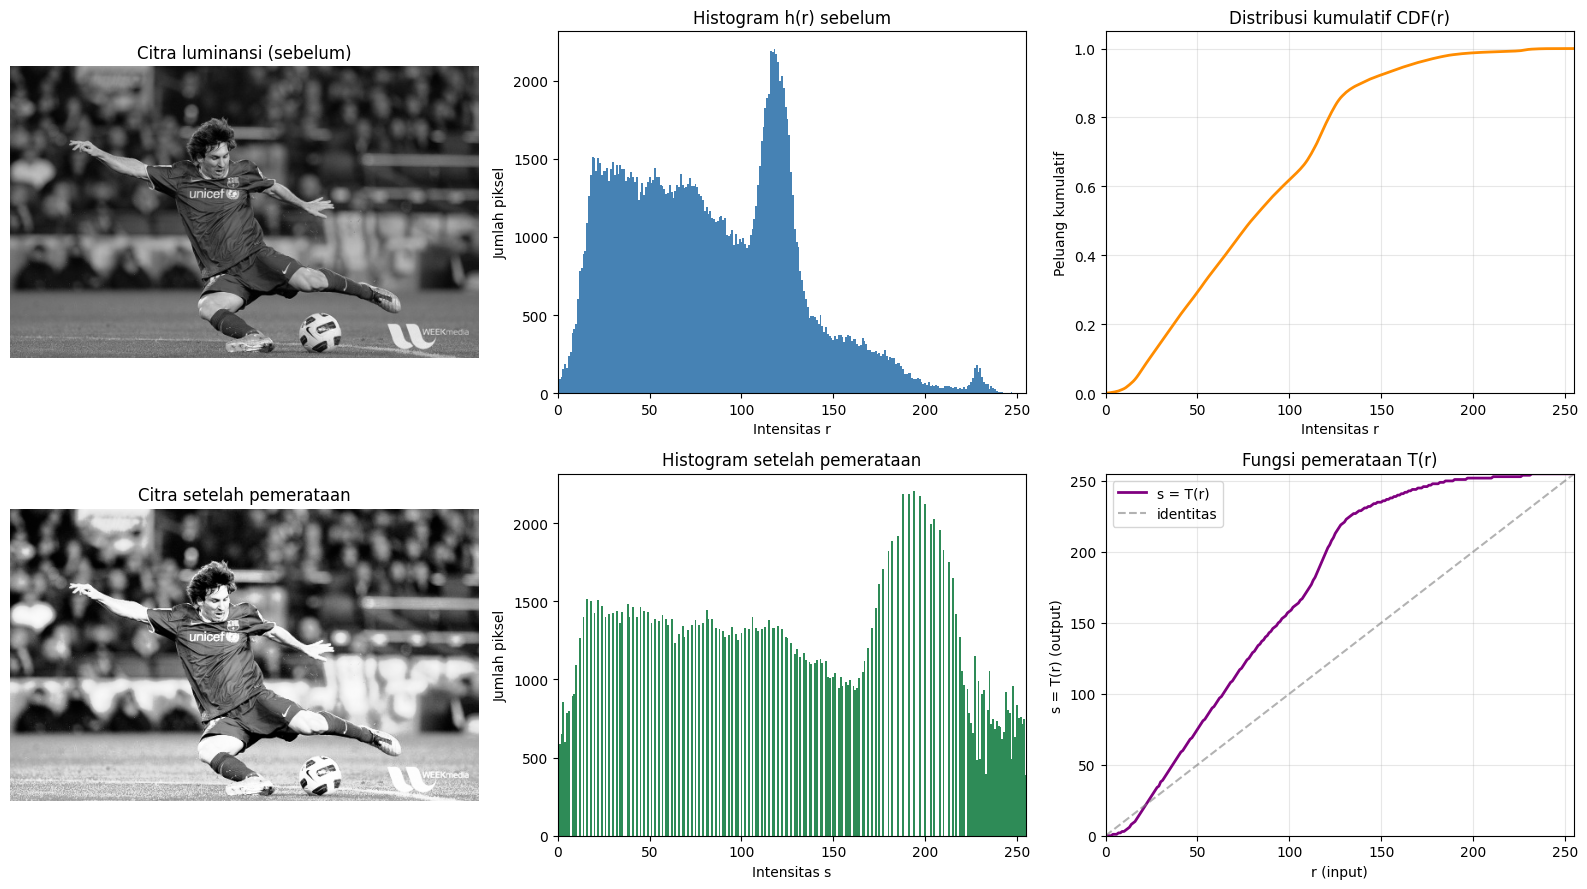

In [4]:
# =============================================================================
# B. Histogram, distribusi kumulatif, dan fungsi pemerataan
# -----------------------------------------------------------------------------
# Tujuan bagian ini:
#   1. Menghitung histogram level abu-abu citra luminansi.
#   2. Mengubah histogram menjadi distribusi peluang (PDF) dan
#      distribusi kumulatif (CDF).
#   3. Membentuk fungsi pemerataan T(r) dari CDF, lalu menerapkannya
#      ke citra (histogram equalization global).
#
# Sel ini MANDIRI. Tidak wajib menjalankan sel A lebih dulu.
# Jika variabel img_gray sudah ada di memori, citra itu yang dipakai.
# Jika belum, citra dimuat lalu dikonversi ke luminansi (rumus sama
# seperti bagian A).
# =============================================================================

import os
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt


def konversi_luminansi(img_bgr):
    """
    Konversi BGR -> luminansi (grayscale perceptually weighted).

    OpenCV membaca citra berwarna dalam urutan B, G, R.
    Mata manusia lebih peka terhadap hijau, jadi bobot G paling besar:

        Y = 0.299*R + 0.587*G + 0.114*B     (ITU-R BT.601)

    Hasil dibulatkan ke bilangan bulat 0..255 (uint8) agar setiap
    piksel punya level abu-abu diskrit, siap dihitung histogramnya.
    """
    blue, green, red = img_bgr[:, :, 0], img_bgr[:, :, 1], img_bgr[:, :, 2]
    luminance = (red * 0.299) + (green * 0.587) + (blue * 0.114)
    return np.round(luminance).astype(np.uint8)


def muat_citra_bgr():
    return cv2.imread(f'{IMAGE_DIR}/messi5.jpg')


# -----------------------------------------------------------------------------
# Pastikan img_gray tersedia sebelum perhitungan
# -----------------------------------------------------------------------------
if "img_gray" in globals() and img_gray is not None:
    print("Memakai img_gray yang sudah ada di memori.")
else:
    print("img_gray belum ada. Memuat citra dan mengonversi luminansi...")
    img_bgr = muat_citra_bgr()
    img_gray = konversi_luminansi(img_bgr)

print(f"Shape img_gray: {img_gray.shape}, dtype: {img_gray.dtype}")

# =============================================================================
# PERHITUNGAN
# Citra 8-bit punya L = 256 level intensitas, r = 0, 1, ..., 255.
# =============================================================================

L = 256                          # jumlah level abu-abu
tinggi, lebar = img_gray.shape   # dimensi citra (baris, kolom)
jumlah_piksel = tinggi * lebar   # N = total piksel, dipakai normalisasi

# -----------------------------------------------------------------------------
# 1) HISTOGRAM h(r)
# -----------------------------------------------------------------------------
# Definisi:
#   h(r) = banyaknya piksel yang intensitasnya tepat sama dengan r.
#
# Contoh: jika h(40) = 1200, berarti ada 1200 piksel bernilai 40.
#
# Implementasi:
#   np.bincount menghitung frekuensi setiap nilai 0..255 sekaligus.
#   .ravel() meratakan matriks 2D menjadi vektor 1D.
#   minlength=L menjamin hasil selalu berukuran 256, meski ada level
#   yang tidak muncul sama sekali (nilainya 0).
#
# Cara manual yang setara (lebih lambat):
#   histogram = np.zeros(256)
#   for i in range(tinggi):
#       for j in range(lebar):
#           histogram[img_gray[i, j]] += 1
# -----------------------------------------------------------------------------
histogram = np.bincount(img_gray.ravel(), minlength=L).astype(np.float64)

# -----------------------------------------------------------------------------
# 2) DISTRIBUSI PELUANG / PDF  p(r)
# -----------------------------------------------------------------------------
# Definisi:
#   p(r) = h(r) / N
#
# Artinya: peluang sebuah piksel acak bernilai r.
# Sifat wajib:
#   - p(r) >= 0 untuk semua r
#   - sum_r p(r) = 1
#
# PDF dipakai karena pemerataan histogram bekerja pada peluang,
# bukan pada hitungan mentah (agar independen terhadap ukuran citra).
# -----------------------------------------------------------------------------
pdf = histogram / jumlah_piksel

# -----------------------------------------------------------------------------
# 3) DISTRIBUSI KUMULATIF / CDF  cdf(r_k)
# -----------------------------------------------------------------------------
# Definisi:
#   cdf(r_k) = p(0) + p(1) + ... + p(r_k)
#            = sum_{j=0..k} p(r_j)
#
# Sifat:
#   - cdf monoton naik (tidak pernah turun)
#   - cdf(255) = 1  (seluruh peluang sudah terakumulasi)
#   - cdf(r) menunjukan "berapa bagian piksel yang intensitasnya <= r"
#
# CDF adalah inti histogram equalization: ia memetakan intensitas
# yang "padat" ke rentang yang lebih lebar, dan yang "jarang" ke
# rentang yang lebih sempit, sehingga histogram cenderung merata.
#
# np.cumsum = jumlah kumulatif elemen array dari kiri ke kanan.
# -----------------------------------------------------------------------------
cdf = np.cumsum(pdf)

# cdf_min = nilai CDF pertama yang tidak nol.
# Diperlukan karena level 0..r tertentu mungkin tidak muncul sama sekali,
# sehingga CDF di ujung kiri bernilai 0. Jika 0 ikut dipakai di rumus
# tanpa dikoreksi, output tidak menempati seluruh rentang 0..255.
cdf_min = cdf[cdf > 0].min()

# -----------------------------------------------------------------------------
# 4) FUNGSI PEMERATAAN T(r)  (histogram equalization mapping)
# -----------------------------------------------------------------------------
# Ide:
#   Cari transformasi s = T(r) sehingga CDF citra keluaran mendekati
#   garis lurus (distribusi seragam).
#
# Rumus dasar (buku Gonzalez & Woods / banyak diktat):
#   s_k = round( (L-1) * cdf(r_k) )
#
# Rumus yang men-stretch penuh ke 0..255 (mendekati OpenCV equalizeHist):
#   s_k = round( (L-1) * (cdf(r_k) - cdf_min) / (1 - cdf_min) )
#
# Hasil T(r) adalah lookup table (LUT) 256 elemen:
#   intensitas lama r  -->  intensitas baru s = fungsi_pemerataan[r]
#
# Karena T(r) hanya bergantung pada CDF global, SEMUA piksel bernilai
# r yang sama akan dipetakan ke s yang sama (pemerataan GLOBAL).
# Inilah bedanya dengan CLAHE di bagian C, yang bekerja per-ubin.
# -----------------------------------------------------------------------------
fungsi_pemerataan = np.round(
    (L - 1) * (cdf - cdf_min) / (1.0 - cdf_min)
).astype(np.uint8)

# Versi rumus dasar (tanpa koreksi cdf_min), disimpan untuk perbandingan
# teoritis. Keduanya biasanya hampir sama jika histogram tidak "bolong"
# di level gelap.
fungsi_pemerataan_dasar = np.round((L - 1) * cdf).astype(np.uint8)

# -----------------------------------------------------------------------------
# 5) TERAPKAN FUNGSI PEMERATAAN KE CITRA
# -----------------------------------------------------------------------------
# Indexing NumPy:
#   img_equalized[i, j] = fungsi_pemerataan[ img_gray[i, j] ]
#
# Satu baris ini mengganti setiap piksel menurut LUT, tanpa loop Python.
# Setelah mapping, histogram baru dihitung ulang untuk verifikasi:
# idealnya lebih "menyebar" ke kiri-kanan, dan CDF-nya lebih linear.
# -----------------------------------------------------------------------------
img_equalized = fungsi_pemerataan[img_gray]

histogram_eq = np.bincount(img_equalized.ravel(), minlength=L).astype(np.float64)
pdf_eq = histogram_eq / jumlah_piksel
cdf_eq = np.cumsum(pdf_eq)

# -----------------------------------------------------------------------------
# Ringkasan numerik (sanity check)
# -----------------------------------------------------------------------------
# Yang harus terpenuhi:
#   sum(histogram) == N
#   sum(pdf)       ~= 1
#   cdf[-1]        ~= 1
print(f"Ukuran citra          : {tinggi} x {lebar} = {jumlah_piksel} piksel")
print(f"Jumlah histogram      : {histogram.sum():.0f}  (harus = N)")
print(f"Sum PDF               : {pdf.sum():.6f}  (harus ~ 1)")
print(f"CDF[0], CDF[255]      : {cdf[0]:.6f}, {cdf[-1]:.6f}")
print(f"cdf_min               : {cdf_min:.6f}")
print("Contoh mapping r -> s (fungsi pemerataan):")
for r in (0, 50, 100, 128, 200, 255):
    print(f"    r={r:3d}  -->  s={fungsi_pemerataan[r]:3d}")

# -----------------------------------------------------------------------------
# Visualisasi
# -----------------------------------------------------------------------------
# Baris 1: citra asli, histogram asli, CDF asli
# Baris 2: citra hasil, histogram hasil, kurva T(r)
#
# Cara membaca plot:
#   - Histogram sebelum biasanya menumpuk di sebagian rentang
#     (misalnya banyak piksel gelap).
#   - CDF sebelum berbentuk "S" atau naik curam di area yang padat.
#   - T(r) adalah CDF yang di-skala ke 0..255; semakin curam T(r),
#     semakin besar peregangan kontras di intensitas itu.
#   - Histogram sesudah lebih tersebar (tidak selalu rata sempurna
#     karena intensitas bersifat diskrit: beberapa r bisa jatuh
#     ke s yang sama).
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Citra luminansi (sebelum)")
axes[0, 0].axis("off")

axes[0, 1].bar(np.arange(L), histogram, width=1.0, color="steelblue")
axes[0, 1].set_title("Histogram h(r) sebelum")
axes[0, 1].set_xlabel("Intensitas r")
axes[0, 1].set_ylabel("Jumlah piksel")
axes[0, 1].set_xlim(0, 255)

axes[0, 2].plot(np.arange(L), cdf, color="darkorange", linewidth=2)
axes[0, 2].set_title("Distribusi kumulatif CDF(r)")
axes[0, 2].set_xlabel("Intensitas r")
axes[0, 2].set_ylabel("Peluang kumulatif")
axes[0, 2].set_xlim(0, 255)
axes[0, 2].set_ylim(0, 1.05)
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].imshow(img_equalized, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title("Citra setelah pemerataan")
axes[1, 0].axis("off")

axes[1, 1].bar(np.arange(L), histogram_eq, width=1.0, color="seagreen")
axes[1, 1].set_title("Histogram setelah pemerataan")
axes[1, 1].set_xlabel("Intensitas s")
axes[1, 1].set_ylabel("Jumlah piksel")
axes[1, 1].set_xlim(0, 255)

axes[1, 2].plot(np.arange(L), fungsi_pemerataan, color="purple", linewidth=2, label="s = T(r)")
axes[1, 2].plot([0, 255], [0, 255], "--", color="gray", alpha=0.6, label="identitas")
axes[1, 2].set_title("Fungsi pemerataan T(r)")
axes[1, 2].set_xlabel("r (input)")
axes[1, 2].set_ylabel("s = T(r) (output)")
axes[1, 2].set_xlim(0, 255)
axes[1, 2].set_ylim(0, 255)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## C. Terapkan CLAHE pada citra tersebut dan bandingkan hasilnya. Berikan penjelasan.

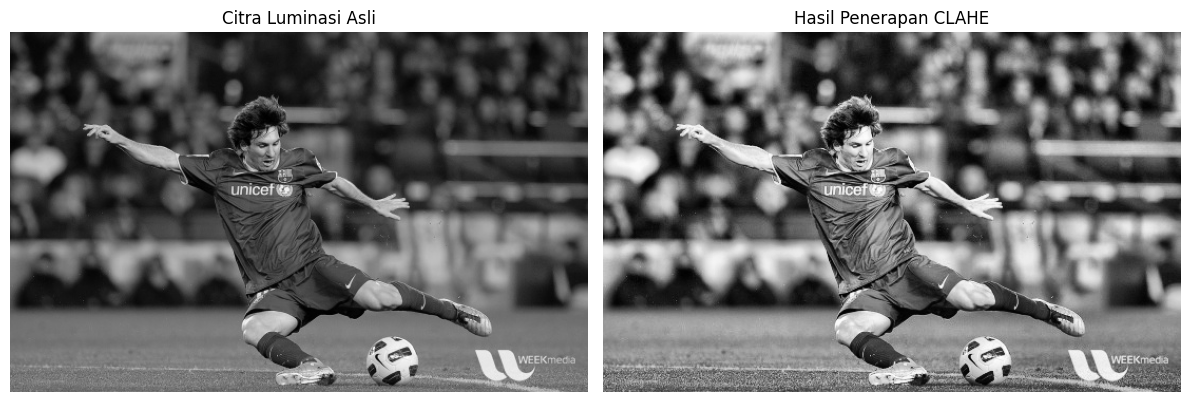

Tampilan Citra Setelah CLAHE:


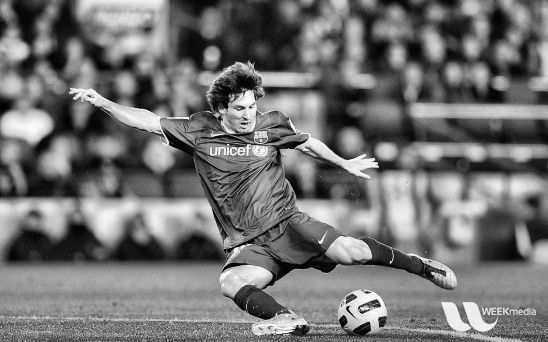

In [5]:
# ==========================================
# SOAL 3c: Terapkan CLAHE pada citra luminasi
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

IMAGE_DIR = "/content/drive/MyDrive"
img_bgr = cv2.imread(f'{IMAGE_DIR}/messi5.jpg')
blue, green, red = img_bgr[:, :, 0], img_bgr[:, :, 1], img_bgr[:, :, 2]
luminance = (red * 0.299) + (green * 0.587) + (blue * 0.114)
img_gray = np.round(luminance).astype(np.uint8)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Luminasi Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_clahe, cmap='gray')
plt.title('Hasil Penerapan CLAHE')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Tampilan Citra Setelah CLAHE:")
cv2_imshow(img_clahe)

## D. Bandingkan hasil tersebut dengan fungsi cv2.adaptiveThreshold. Berikan analisa Anda.

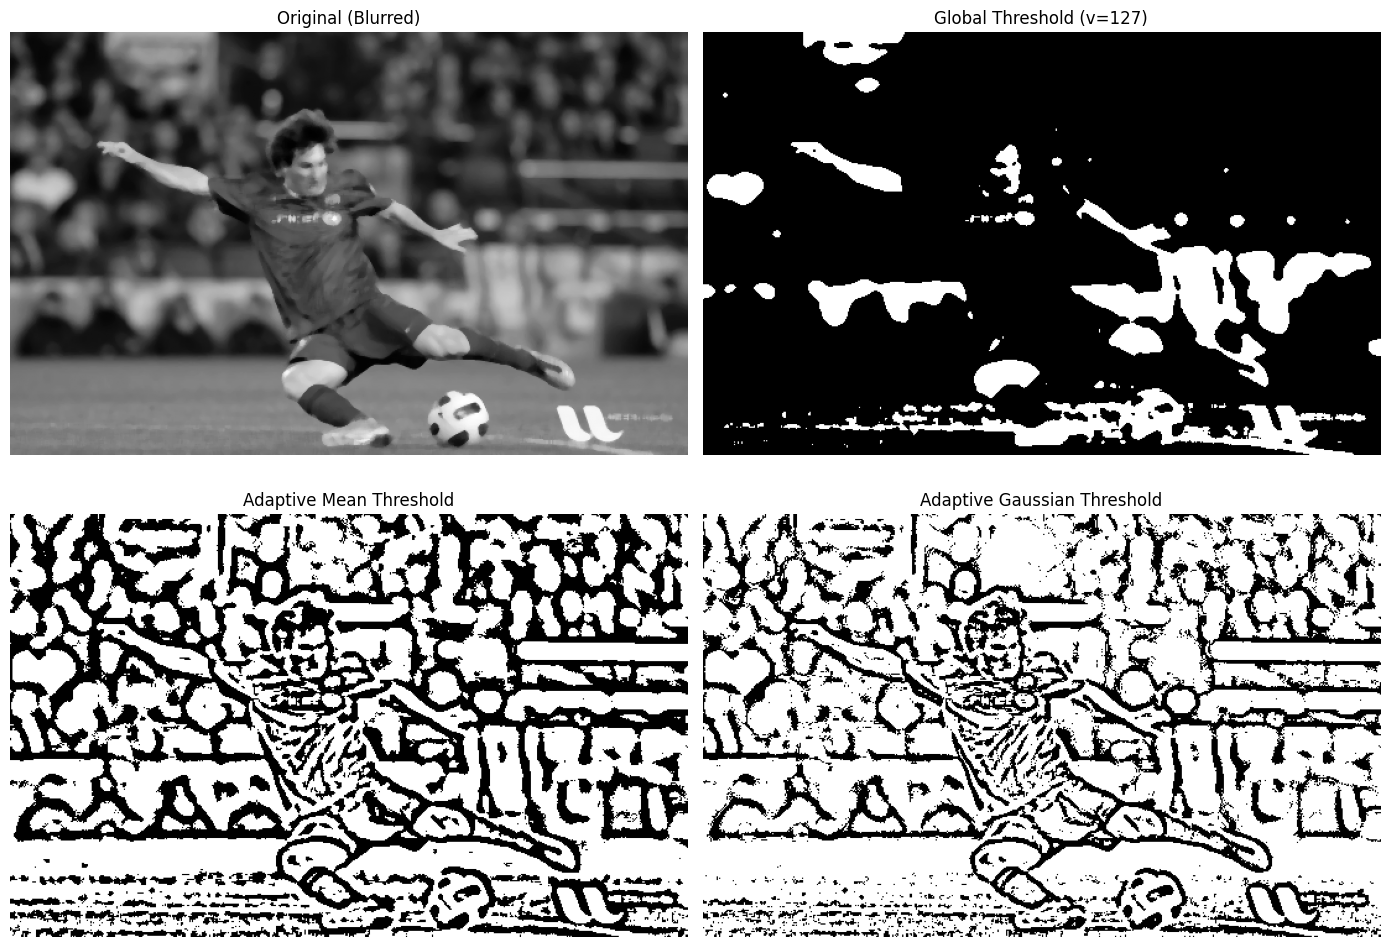

In [6]:
# ==========================================
# SOAL 3d: Perbandingan dengan cv2.adaptiveThreshold
# Referensi: https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = "/content/drive/MyDrive"
img_bgr = cv2.imread(f'{IMAGE_DIR}/messi5.jpg')
blue, green, red = img_bgr[:, :, 0], img_bgr[:, :, 1], img_bgr[:, :, 2]
luminance = (red * 0.299) + (green * 0.587) + (blue * 0.114)
img_gray = np.round(luminance).astype(np.uint8)

img_blur = cv2.medianBlur(img_gray, 5)

_, th_global = cv2.threshold(img_blur, 127, 255, cv2.THRESH_BINARY)
th_mean = cv2.adaptiveThreshold(
    img_blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2
)
th_gauss = cv2.adaptiveThreshold(
    img_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)

titles = [
    'Original (Blurred)',
    'Global Threshold (v=127)',
    'Adaptive Mean Threshold',
    'Adaptive Gaussian Threshold'
]
images = [img_blur, th_global, th_mean, th_gauss]

plt.figure(figsize=(14, 10))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()